# <center> 💧 WATER POTABILITY PREDICTION 💧 </center>

# <center><img src="https://media0.giphy.com/media/v1.Y2lkPTc5MGI3NjExZTVveHQ2ZXV1MjNpNWFpaGxlNHM0eTFrMmtqdW52em1ramJ6M3BiZiZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9Zw/3oKIPxqCgocGHGtGTK/giphy.gif" width= 250></center>

# Step 1: Introduction

***Access to clean and safe drinking water is a basic necessity for human health. However, water sources are often contaminated by natural impurities and human activities, making it essential to evaluate water quality before use. Traditional laboratory testing methods, while accurate, can be time-consuming and resource-intensive.***

***In this project, we aim to develop a machine learning model for water potability prediction using various water quality parameters such as pH, hardness, solids, chloramines, sulphate, conductivity, organic carbon, trihalomethanes, and turbidity. The model will determine whether water is safe to drink based on these factors. This approach may provide faster, more cost-effective, and data-driven insights into public health and water resource management***

# Attributes Information

## Determine the potability of water (potability = 1) or its non-potability (potability = 0) based on its chemical and physical characteristics.
1. pH → Indicates the acidity or alkalinity of water (range 0–14).
2. Hardness → Measures dissolved calcium and magnesium minerals in water.
3. Solids → Total dissolved solids (TDS), representing salts and organic matter.
4. Chloramines → Residual disinfectant formed from chlorine and ammonia used in water treatment.
5. Sulphate → Concentration of sulphate ions, which can affect taste and cause scaling.
6. Conductivity → The ability of water to conduct electricity is linked to ion concentration.
7. Organic Carbon → Amount of carbon-based organic matter present in water.
8. Trihalomethanes → By-products of chlorine disinfection, potentially harmful at high levels.
9. Turbidity → Cloudiness of water caused by suspended particles.
10. Potability → Target label indicating if water is safe to drink (1 = potable, 0 = not potable).

# Project Overview:
The project aims to develop a machine learning model to predict water potability based on various water quality parameters. This model will help in assessing whether water is safe for consumption, which is crucial for public health and water management.

# Step 2: Importing Essential Libraries, Metrics, Tools & Models

In [1]:
#Importing Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from collections import Counter
import joblib
warnings.filterwarnings("ignore")

# Important Functions

from sklearn.model_selection import train_test_split,cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report,confusion_matrix,roc_auc_score,roc_curve
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE
from sklearn.pipeline import Pipeline
from sklearn.datasets import make_classification
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

from sklearn.datasets import make_classification

# Model Selection & Training
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn. ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

# Step 3: Loading The Data

In [2]:
df = pd.read_csv("water_potability.csv")

# Step 4: Data Preprocessing

### Taking a look at the first 5 rows of the dataset

In [3]:
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


### Checking the shape—i.e., size—of the data

In [4]:
df.shape

(3276, 10)

### Learning the data-types of columns and how many non-null values there are in those columns

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


### Getting the statistical summary of the dataset

In [6]:
df.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


# Handling Missing Values and Duplicates

### As we can see, there are missing values in columns "ph", "Sulfate", and "Trihalomethanes"

In [7]:
df.isnull().sum()

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

In [8]:
df.fillna(df.median(), inplace=True)

In [9]:
df.isnull().sum()

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

#### It seems that there is no duplicates in the dataset

In [10]:
df.duplicated().sum()

0

# Step 5: Exploratory Data Analysis

## Check Data Distributions
## Histogram

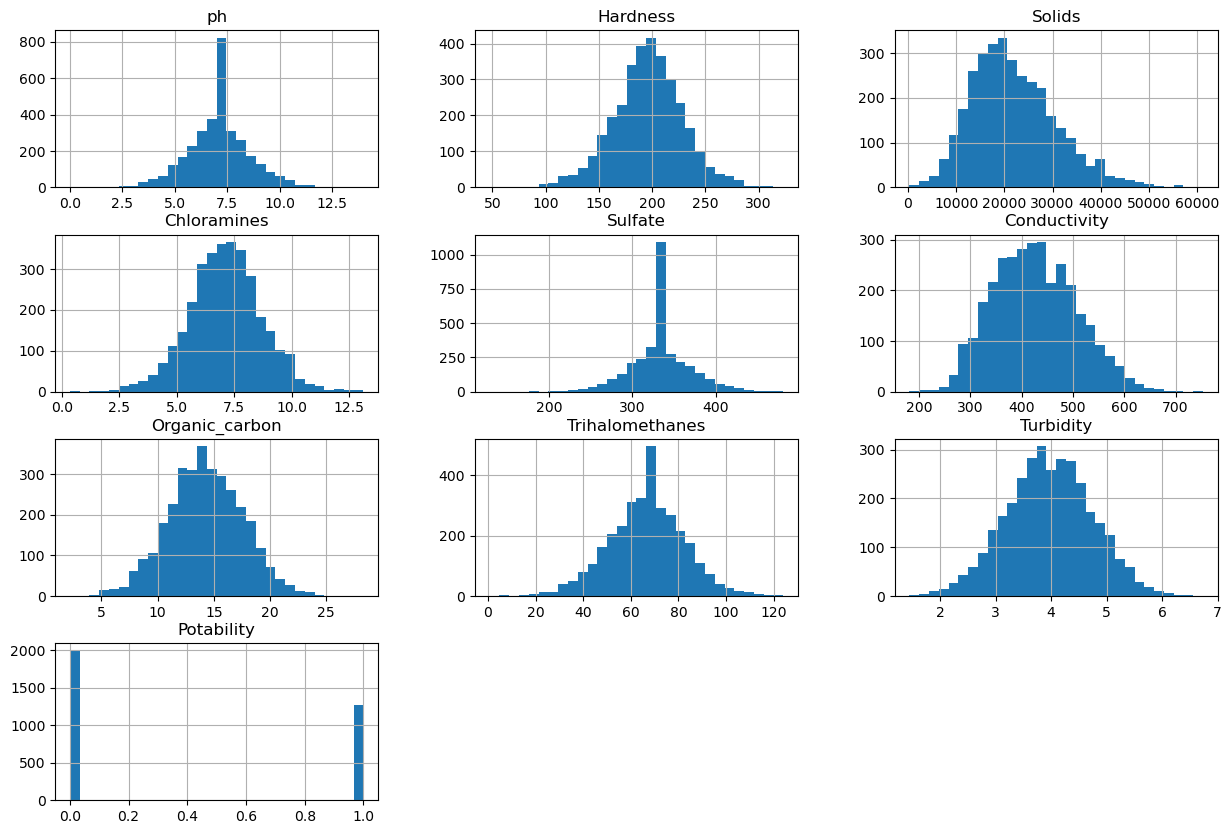

In [11]:
# Distribution of each column
df.hist(bins=30, figsize=(15,10))
plt.show()

## Countplot

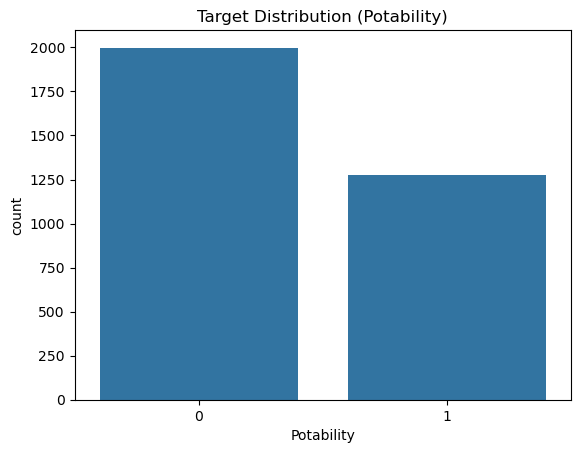

In [12]:
# Distribution of target variable
sns.countplot(x="Potability", data=df)
plt.title("Target Distribution (Potability)")
plt.show()

## Boxplot

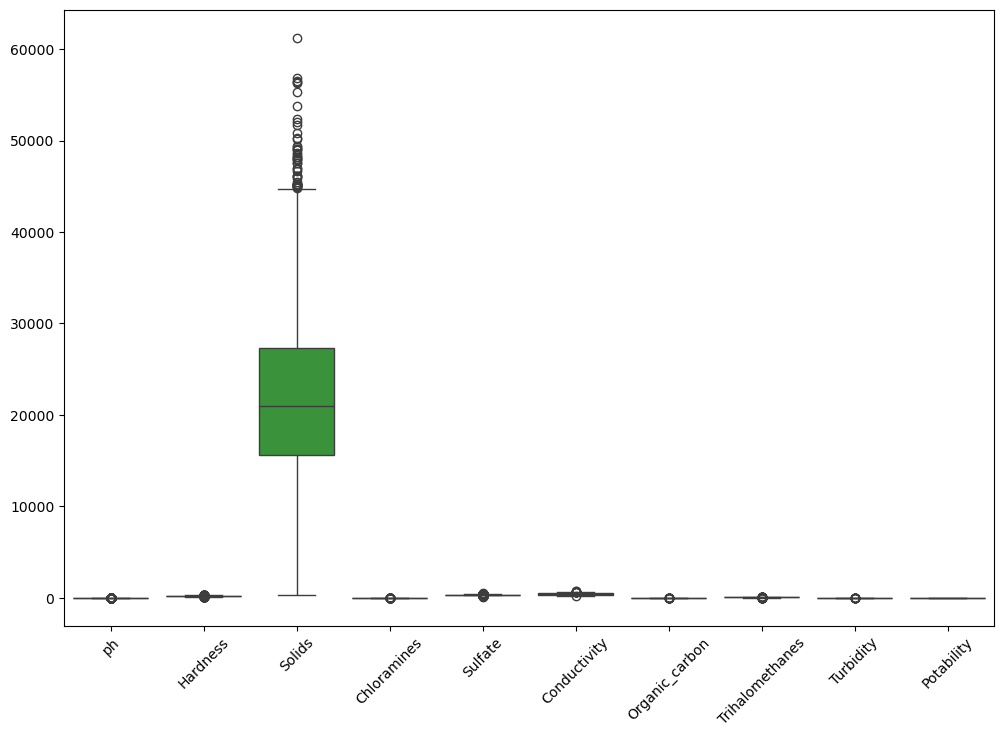

In [13]:
# Boxplots to check outliers
plt.figure(figsize=(12,8))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.show()

## Correlation Heatmap

#### Visualizing the linear correlations between variables using Heatmap Visualization. The measure used for finding the linear correlation between each variable is Pearson Correlation Coefficient

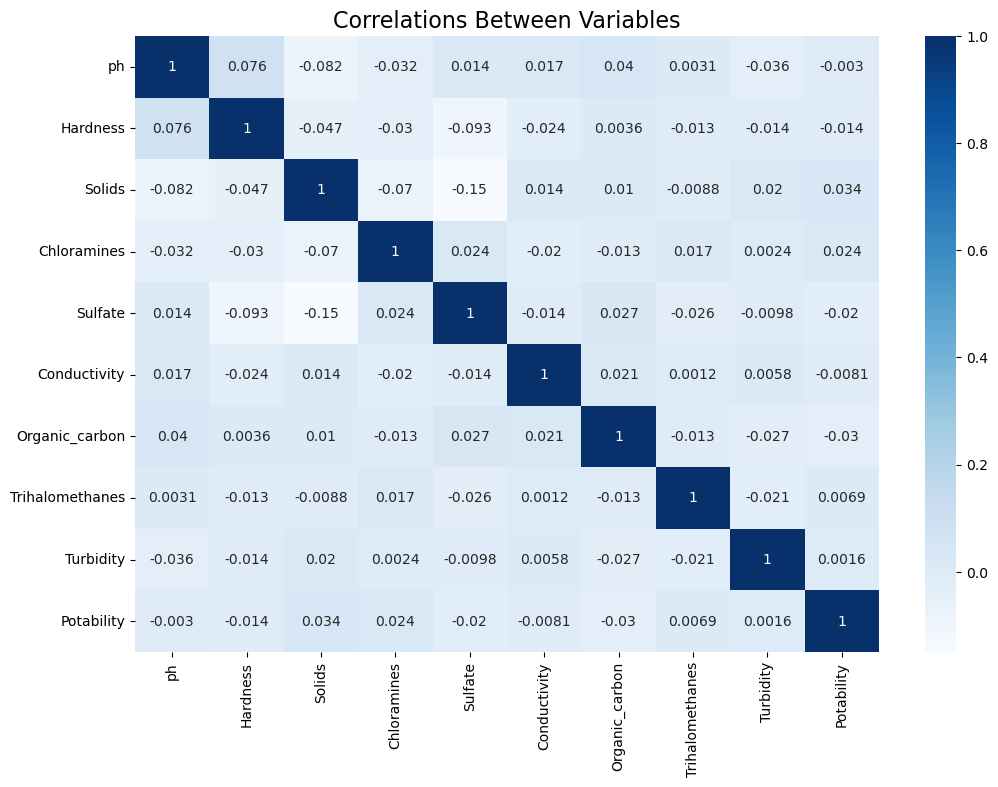

In [14]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap="Blues")
plt.title("Correlations Between Variables", size=16)
plt.show()

## Handling Outliers

In [15]:
# Handle Outliers
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
df = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

# Step 6:Train-Test Split

In [16]:
# Define X, y
X = df.drop(columns='Potability',axis=1)
y = df.Potability

### Splitting the Data into Train-Test

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

### SMOTE

In [18]:
# SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print("After SMOTE class distribution:", Counter(y_train_res))

After SMOTE class distribution: Counter({0: 1170, 1: 1170})


### SCALING

In [19]:
#Scaling Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# Step 7: Model Selection and Training

## 1. Logistic Regression

In [20]:
# Initialize and train
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train_res)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [21]:
y_pred_lr = lr_model.predict(X_test_scaled)
y_proba_lr = lr_model.predict_proba(X_test_scaled)[:,1]

In [22]:
print("\nLogistic Regression Metrics:")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
roc_score_lr = roc_auc_score(y_test, y_proba_lr)
print("ROC AUC Score:", roc_score_lr)


Logistic Regression Metrics:
Confusion Matrix:
 [[243 258]
 [150 149]]

Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.49      0.54       501
           1       0.37      0.50      0.42       299

    accuracy                           0.49       800
   macro avg       0.49      0.49      0.48       800
weighted avg       0.52      0.49      0.50       800

Accuracy: 0.49
ROC AUC Score: 0.4755839491585391


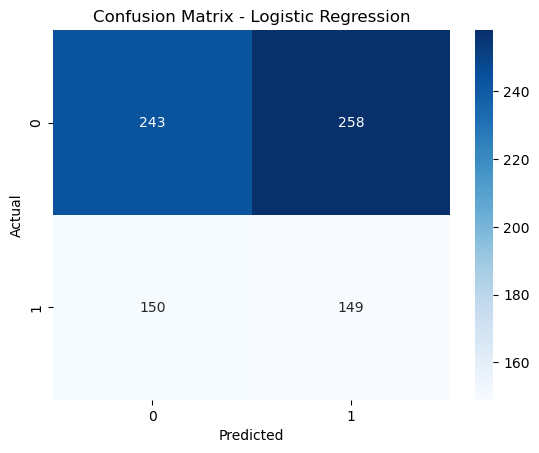

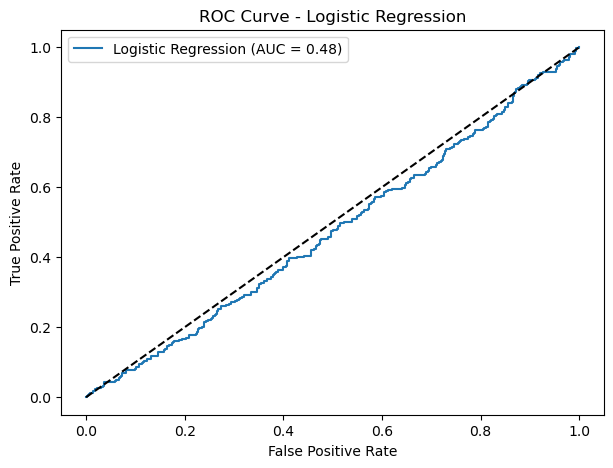

In [23]:
# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion Matrix - Logistic Regression")
plt.show()

#Plot ROC Curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
plt.figure(figsize=(7,5))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_score_lr:.2f})')
plt.plot([0,1],[0,1], "k--")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate"); plt.title("ROC Curve - Logistic Regression")
plt.legend(); plt.show()

## 2. Support Vector Classifier (SVC)

In [24]:
svc_model = SVC(probability=True, random_state=42)  # probability=True needed for ROC AUC
svc_model.fit(X_train_scaled, y_train_res)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [25]:
# Predictions
y_pred_svc = svc_model.predict(X_test_scaled)
y_proba_svc = svc_model.predict_proba(X_test_scaled)[:,1]

In [26]:
# Evaluation Metrics
print("\nSVC Metrics:")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svc))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svc))
print("Accuracy:", accuracy_score(y_test, y_pred_svc))
roc_score_svc = roc_auc_score(y_test, y_proba_svc)
print("ROC AUC Score:", roc_score_svc)


SVC Metrics:
Confusion Matrix:
 [[296 205]
 [123 176]]

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.59      0.64       501
           1       0.46      0.59      0.52       299

    accuracy                           0.59       800
   macro avg       0.58      0.59      0.58       800
weighted avg       0.62      0.59      0.60       800

Accuracy: 0.59
ROC AUC Score: 0.6315596232284594


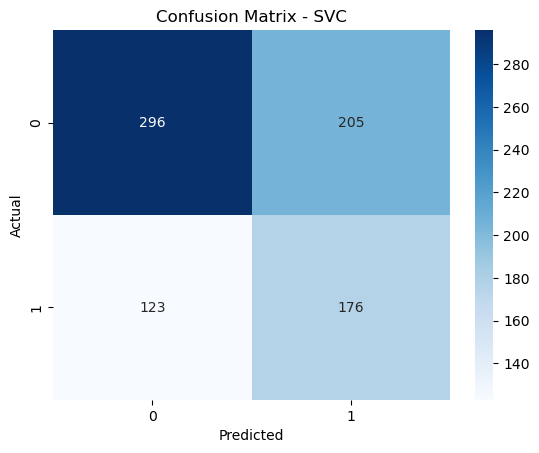

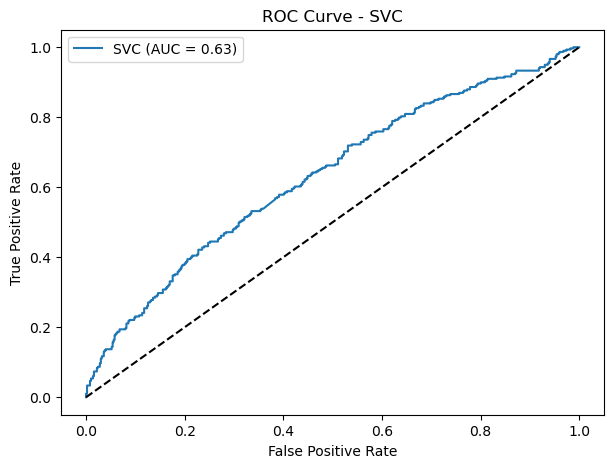

In [27]:
# Confusion Matrix Plot
sns.heatmap(confusion_matrix(y_test, y_pred_svc), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion Matrix - SVC")
plt.show()

# ROC Curve
fpr_svc, tpr_svc, _ = roc_curve(y_test, y_proba_svc)
plt.figure(figsize=(7,5))
plt.plot(fpr_svc, tpr_svc, label=f'SVC (AUC = {roc_score_svc:.2f})')
plt.plot([0,1],[0,1], "k--")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate"); plt.title("ROC Curve - SVC")
plt.legend(); plt.show()

## 3. Random Forest

In [28]:
# Initialize and train
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train_res)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [29]:
# Prediction
y_pred_rf = rf.predict(X_test_scaled)
y_proba_rf = rf.predict_proba(X_test_scaled)[:, 1]

In [30]:
# Evaluation Metrics
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
roc_score_rf = roc_auc_score(y_test, y_proba_rf)
print("ROC AUC Score:", roc_score_rf)

Confusion Matrix:
 [[344 157]
 [162 137]]

Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.69      0.68       501
           1       0.47      0.46      0.46       299

    accuracy                           0.60       800
   macro avg       0.57      0.57      0.57       800
weighted avg       0.60      0.60      0.60       800

Accuracy: 0.60125
ROC AUC Score: 0.6129613682334328


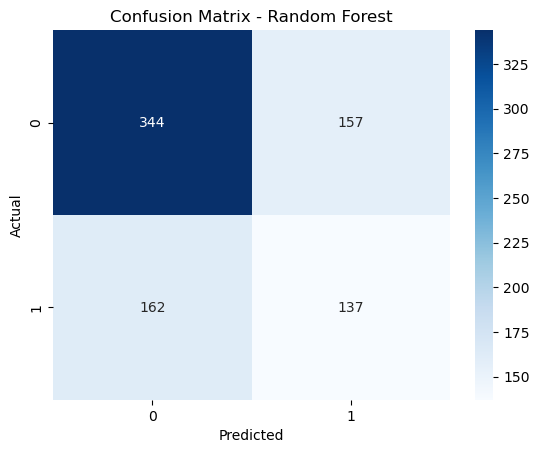

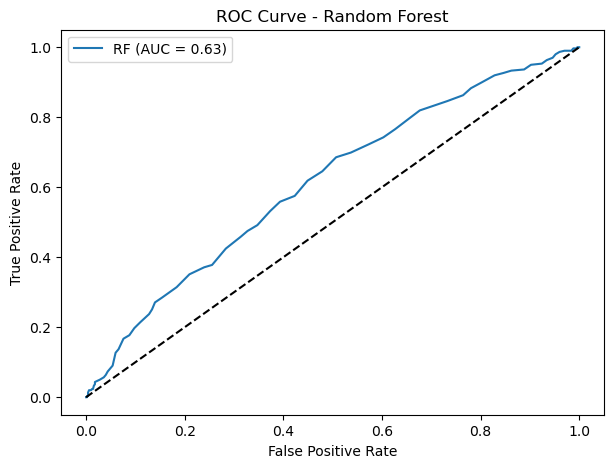

In [31]:
# Confusion Matrix Plot
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion Matrix - Random Forest")
plt.show()

# ROC Curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
plt.figure(figsize=(7,5))
plt.plot(fpr_rf, tpr_rf, label=f'RF (AUC = {roc_score_svc:.2f})')
plt.plot([0,1],[0,1], "k--")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate"); plt.title("ROC Curve - Random Forest")
plt.legend(); plt.show()

## 4. K-Nearest Neighbors

In [32]:
# Initialize and train
knn = KNeighborsClassifier(n_neighbors= 1)
knn.fit(X_train_scaled, y_train_res)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",1
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [33]:
# Prediction
y_pred_knn = knn.predict(X_test_scaled)
y_proba_knn = knn.predict_proba(X_test_scaled)[:, 1]

In [34]:
# Evaluation Metrics
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
roc_score_knn = roc_auc_score(y_test, y_proba_knn)
print("ROC AUC Score:", roc_score_knn)

Confusion Matrix:
 [[302 199]
 [150 149]]

Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.60      0.63       501
           1       0.43      0.50      0.46       299

    accuracy                           0.56       800
   macro avg       0.55      0.55      0.55       800
weighted avg       0.58      0.56      0.57       800

Accuracy: 0.56375
ROC AUC Score: 0.5505610851874845


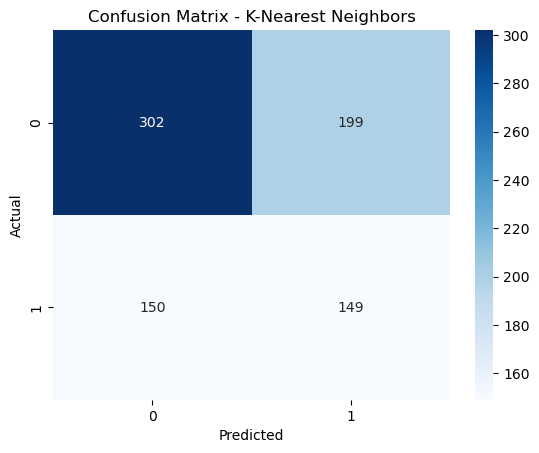

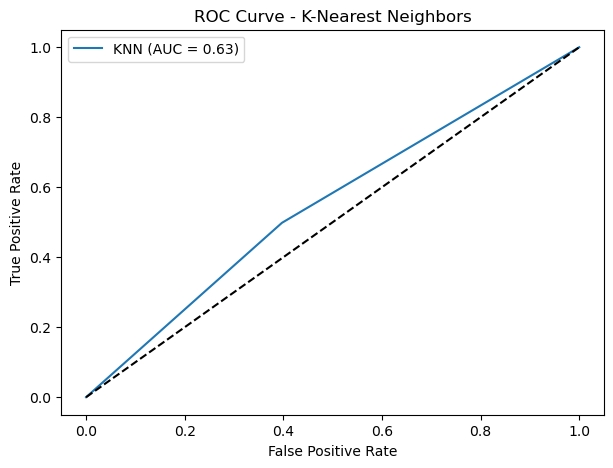

In [35]:
# Confusion Matrix Plot
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion Matrix - K-Nearest Neighbors")
plt.show()

# ROC Curve
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_proba_knn)
plt.figure(figsize=(7,5))
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {roc_score_svc:.2f})')
plt.plot([0,1],[0,1], "k--")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate"); plt.title("ROC Curve - K-Nearest Neighbors")
plt.legend(); plt.show()

## 5. Decision Tree

In [36]:
# Initialize and train
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_scaled, y_train_res)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [37]:
# Prediction
y_pred_dt = dt.predict(X_test_scaled)
y_proba_dt = dt.predict_proba(X_test_scaled)[:, 1]

In [38]:
# Evaluation Metrics
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
roc_score_dt = roc_auc_score(y_test, y_proba_dt)
print("ROC AUC Score:", roc_score_dt)

Confusion Matrix:
 [[272 229]
 [143 156]]

Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.54      0.59       501
           1       0.41      0.52      0.46       299

    accuracy                           0.54       800
   macro avg       0.53      0.53      0.53       800
weighted avg       0.56      0.54      0.54       800

Accuracy: 0.535
ROC AUC Score: 0.5323266510457346


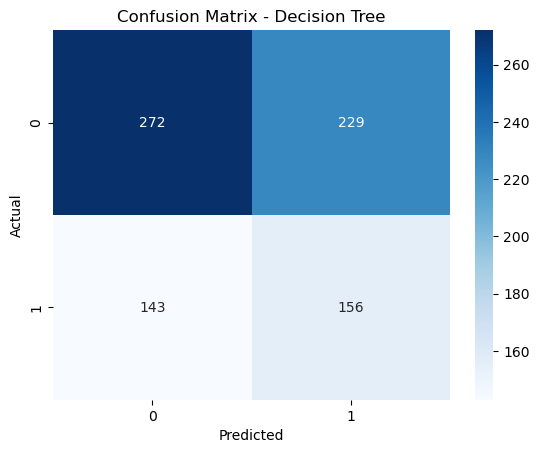

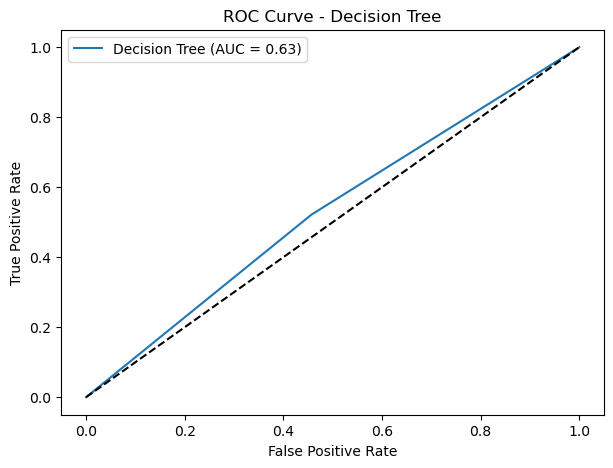

In [39]:
# Confusion Matrix Plot
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion Matrix - Decision Tree")
plt.show()

# ROC Curve0
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba_dt)
plt.figure(figsize=(7,5))
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {roc_score_svc:.2f})')
plt.plot([0,1],[0,1], "k--")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate"); plt.title("ROC Curve - Decision Tree")
plt.legend(); plt.show()

## 6. XGBoost Classifier With Cross-Validation

In [40]:
# Initialize and train
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X_train_scaled, y_train_res)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [41]:
# Prediction
y_pred_xgb = xgb.predict(X_test_scaled)
y_proba_xgb = xgb.predict_proba(X_test_scaled)[:, 1]

In [42]:
# Evaluation Metrics
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
roc_score_xgb = roc_auc_score(y_test, y_proba_xgb)
print("ROC AUC Score:", roc_score_xgb)

Confusion Matrix:
 [[319 182]
 [153 146]]

Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.64      0.66       501
           1       0.45      0.49      0.47       299

    accuracy                           0.58       800
   macro avg       0.56      0.56      0.56       800
weighted avg       0.59      0.58      0.58       800

Accuracy: 0.58125
ROC AUC Score: 0.5917395977276216


In [43]:
# Validation metrics
cv_xgb = cross_val_score(xgb, X_train_scaled, y_train_res, cv=5, scoring='accuracy')
print("Cross-Validation Accuracy (5-fold):", cv_xgb.mean())

Cross-Validation Accuracy (5-fold): 0.6611111111111111


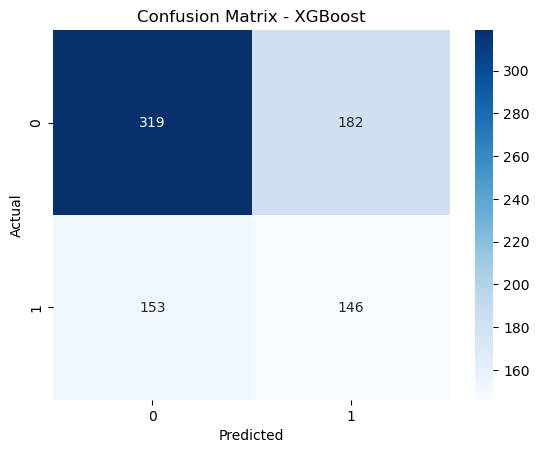

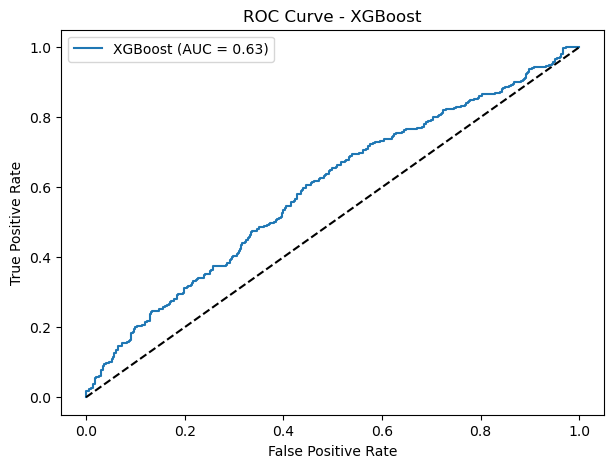

In [44]:
# Confusion Matrix Plot
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion Matrix - XGBoost")
plt.show()

# ROC Curve0
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
plt.figure(figsize=(7,5))
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_score_svc:.2f})')
plt.plot([0,1],[0,1], "k--")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate"); plt.title("ROC Curve - XGBoost")
plt.legend(); plt.show()

# Step 8:Hyperparameter Tuning

## Random Forest using RandomizedSearchCV

In [45]:
# Parameter grid
rf_param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt'],
    'bootstrap': [True]
}

# Initialise model
rf = RandomForestClassifier(random_state=42)

# Randomised search
rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_param_dist,
    n_iter=20,  # number of different combinations to try
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42)

rf_random.fit(X_train_res, y_train_res)

print("Best Parameters:", rf_random.best_params_)
print("Best CV Score:", rf_random.best_score_)

best_rf = rf_random.best_estimator_
y_pred_rf = best_rf.predict(X_test)

Best Parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 30, 'bootstrap': True}
Best CV Score: 0.6914529914529914


## XGBoost with RandomizedSearchCV

In [46]:
# Parameter Grid
xgboost_param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.6, 0.8],
    "colsample_bytree": [0.6, 0.8]
}

xgboost_random = RandomizedSearchCV(
    XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42),
    param_distributions=xgboost_param_dist,
    n_iter=20,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    random_state=42)
xgboost_random.fit(X_train_scaled, y_train_res)

print("Best Parameters (XGBoost):", xgboost_random.best_params_)
print("Best CV Score:", xgboost_random.best_score_)
best_xgboost = xgboost_random.best_estimator_
y_pred_xgboost = best_xgboost.predict(X_test_scaled)

Best Parameters (XGBoost): {'subsample': 0.6, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Best CV Score: 0.6705128205128206


# Step 9: Feature Importance (Tree-based Models)

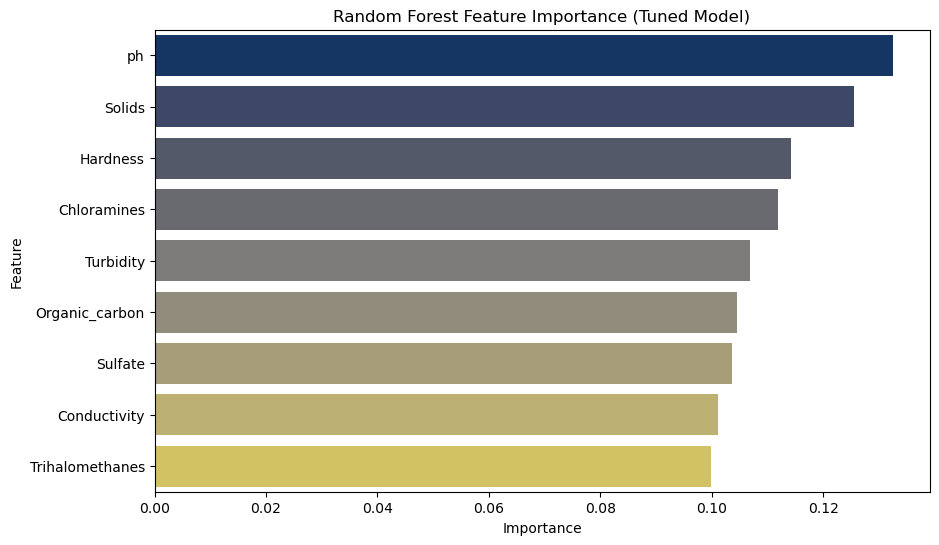

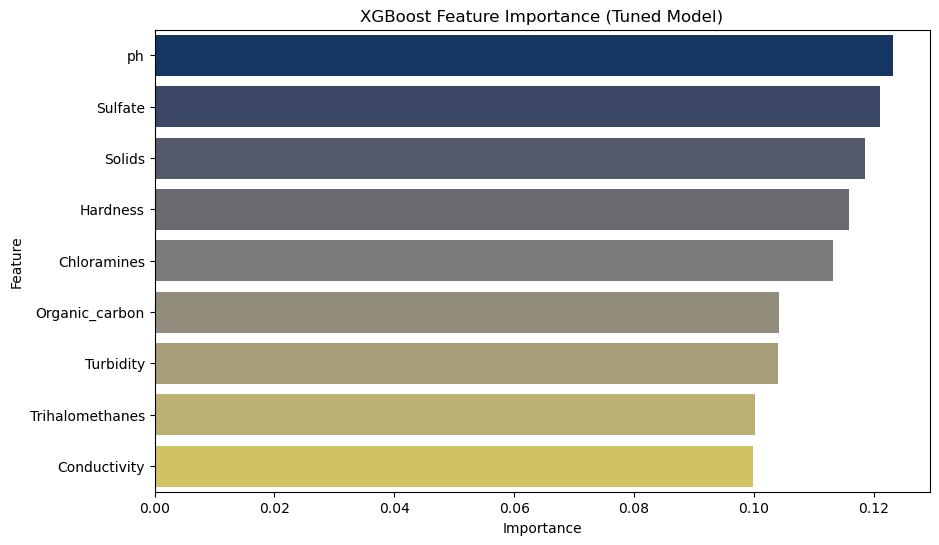

In [47]:
# Feature Importance for Random Forest
rf_feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=rf_feat_imp, hue ='Feature', palette='cividis')
plt.title('Random Forest Feature Importance (Tuned Model)')
plt.show()

# Feature Importance for XGBoost
xgboost_feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_xgboost.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=xgboost_feat_imp, hue ='Feature', palette='cividis')
plt.title('XGBoost Feature Importance (Tuned Model)')
plt.show()

# Step 10 : Compare Model Performances

## Accuracy vs Precision Plot 

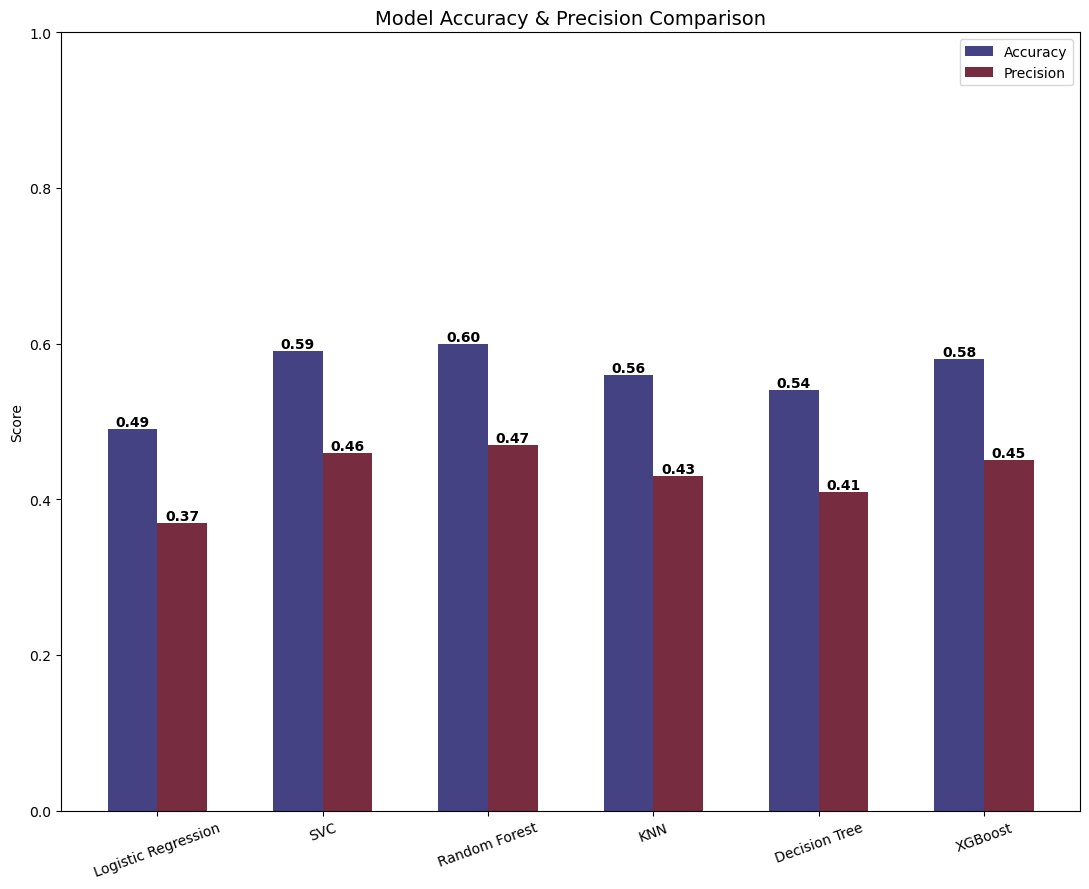

In [48]:
# Step 1: Model names
models = ['Logistic Regression', 'SVC','Random Forest', 'KNN', 'Decision Tree', 'XGBoost']

# Step 2: Accuracy & Precision
accuracies = [0.49, 0.59, 0.60, 0.56, 0.54, 0.58]
precisions = [0.37, 0.46, 0.47, 0.43, 0.41, 0.45]

# Step 3: Setup
x = np.arange(len(models))
width = 0.3

# Step 4: Colors
colors = sns.color_palette("icefire", n_colors=2)

# Step 5: Plot
plt.figure(figsize=(11, 9))

bars1 = plt.bar(x - width/2, accuracies, width, label='Accuracy', color=colors[0])
bars2 = plt.bar(x + width/2, precisions, width, label='Precision', color=colors[1])

# Add value labels for Accuracy
for p in bars1:
    plt.annotate(f"{p.get_height():.2f}",
                 (p.get_x() + p.get_width()/2., p.get_height()),
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

# Add value labels for Precision
for p in bars2:
    plt.annotate(f"{p.get_height():.2f}",
                 (p.get_x() + p.get_width()/2., p.get_height()),
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

# Labels and styling
plt.xticks(x, models, rotation=20)
plt.ylabel("Score")
plt.ylim(0, 1)
plt.title("Model Accuracy & Precision Comparison", fontsize=14)
plt.legend()

plt.tight_layout()
plt.show()

## Recall vs F1-Score vs ROC-AUC Score Plot 

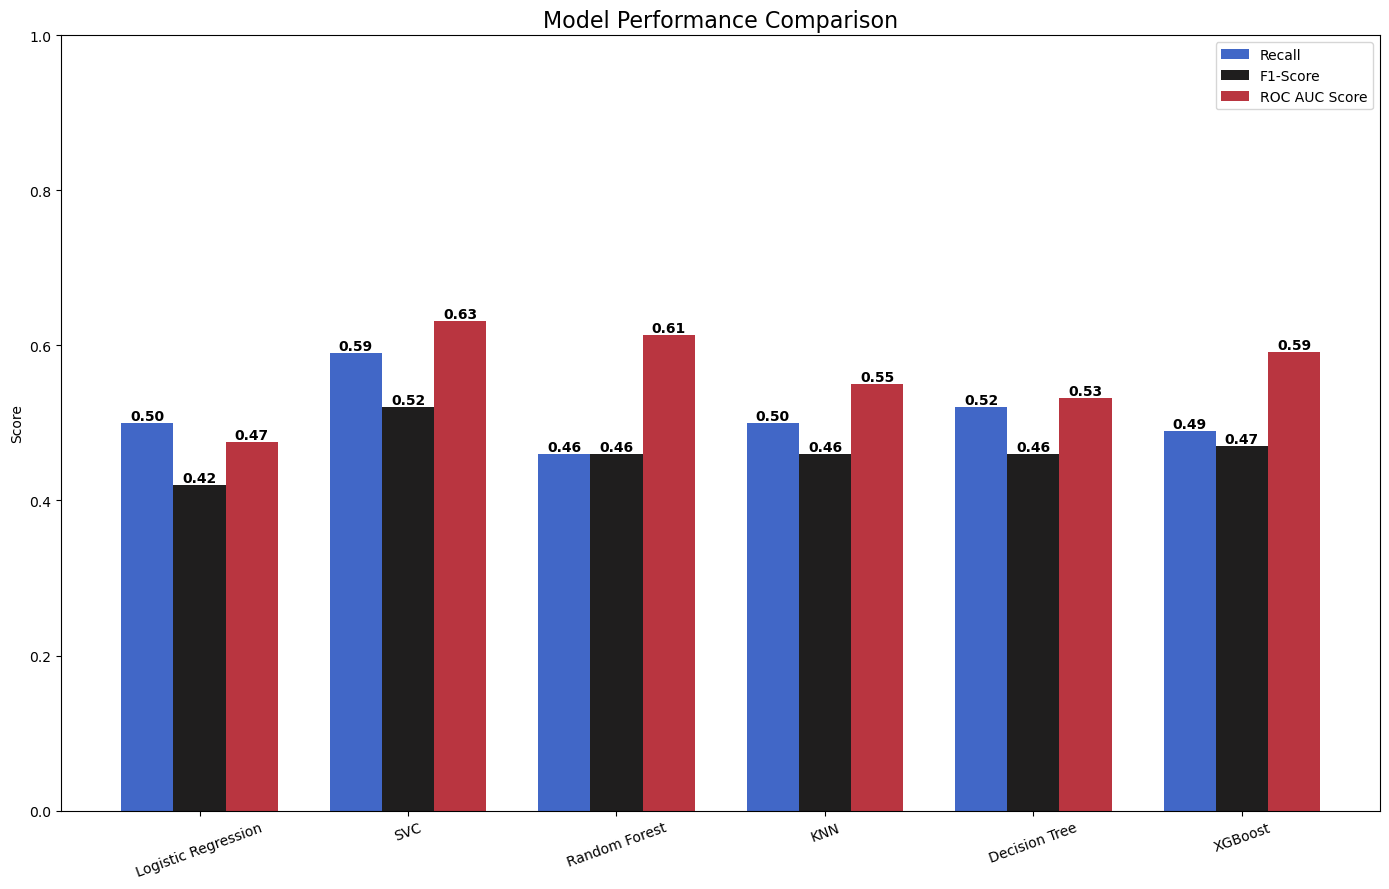

In [49]:
# Step 1: Define model names and scores
models = ['Logistic Regression', 'SVC', 'Random Forest', 'KNN', 'Decision Tree', 'XGBoost']
recalls = [0.50, 0.59, 0.46, 0.50, 0.52, 0.49]
f1_scores = [0.42, 0.52, 0.46, 0.46, 0.46, 0.47]
roc_aucs = [0.475, 0.631, 0.613, 0.550, 0.532, 0.591]

# Step 2: Setup bar positions
x = np.arange(len(models))
width = 0.25

# Step 3: Colors
colors = sns.color_palette("icefire", n_colors=3)

# Step 4: Plot
plt.figure(figsize=(14,9))

bars1 = plt.bar(x - width, recalls, width, label='Recall', color=colors[0])
bars2 = plt.bar(x, f1_scores, width, label='F1-Score', color=colors[1])
bars3 = plt.bar(x + width, roc_aucs, width, label='ROC AUC Score', color=colors[2])

# Step 5: Add value labels

# Recall
for p in bars1:
    plt.annotate(f"{p.get_height():.2f}",
                 (p.get_x() + p.get_width()/2., p.get_height()),
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

# F1 Score
for p in bars2:
    plt.annotate(f"{p.get_height():.2f}",
                 (p.get_x() + p.get_width()/2., p.get_height()),
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

# ROC AUC
for p in bars3:
    plt.annotate(f"{p.get_height():.2f}",
                 (p.get_x() + p.get_width()/2., p.get_height()),
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

# Step 6: Labels
plt.xticks(x, models, rotation=20)
plt.ylabel("Score")
plt.ylim(0, 1)
plt.title("Model Performance Comparison", fontsize=16)
plt.legend()

plt.tight_layout()
plt.show()

# Step 11: Conclusion

This project demonstrated how machine learning can effectively predict the potability of water.

* EDA and feature engineering revealed important patterns in chemical properties such as pH, sulfate, and hardness, which play a significant role in determining water quality.

* SMOTE was applied to handle class imbalance, ensuring that the model learned equally well from both potable and non-potable water samples.

* Multiple models were tested, and Support Vector Classifier (SVC) emerged as the best-performing model, offering strong and balanced results across Accuracy, Precision, Recall, F1-score, and ROC AUC.

The final model can support water quality assessment, assist authorities in monitoring safe drinking water standards, and help in taking timely corrective actions.